In [67]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
from langchain.agents import AgentState

class CustomState(AgentState):
    favourite_colour: str

## Write to state

In [4]:
from langchain.tools import tool, ToolRuntime
from langgraph.types import Command
from langchain.messages import ToolMessage

@tool
def update_favourite_colour(favourite_colour: str, runtime: ToolRuntime) -> Command:
    """Update the favourite colour of the user in the state once they've revealed it."""
    return Command(update={
        "favourite_colour": favourite_colour, 
        "messages": [ToolMessage("Successfully updated favourite colour", tool_call_id=runtime.tool_call_id)]}
        )

In [5]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

agent = create_agent(
    "groq:openai/gpt-oss-20b",
    tools=[update_favourite_colour],
    checkpointer=InMemorySaver(),
    state_schema=CustomState
)

In [6]:
from langchain.messages import HumanMessage

response = agent.invoke(
    { "messages": [HumanMessage(content="My favourite colour is green")]},
    {"configurable": {"thread_id": "1"}}
)

In [7]:
from pprint import pprint

pprint(response)

{'favourite_colour': 'green',
 'messages': [HumanMessage(content='My favourite colour is green', additional_kwargs={}, response_metadata={}, id='a2730c3d-96ee-4ebe-8ee6-33fa260fd7bd'),
              AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to call function update_favourite_colour with favourite_colour: "green".', 'tool_calls': [{'id': 'fc_3bb177f1-f536-44d2-98b8-9aa5d0d8f640', 'function': {'arguments': '{"favourite_colour":"green"}', 'name': 'update_favourite_colour'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 137, 'total_tokens': 181, 'completion_time': 0.046971394, 'completion_tokens_details': {'reasoning_tokens': 17}, 'prompt_time': 0.007013094, 'prompt_tokens_details': None, 'queue_time': 0.148787829, 'total_time': 0.053984488}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_8e23cedc90', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider'

In [8]:
response = agent.invoke(
    { 
        "messages": [HumanMessage(content="Hello, how are you?")],
        "favourite_colour": "green"
    },
    {"configurable": {"thread_id": "10"}}
)

pprint(response)

{'favourite_colour': 'green',
 'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='2bf2e690-61ed-4415-ae07-e5b597483887'),
              AIMessage(content="Hello! I'm doing great—thanks for asking. How can I help you today?", additional_kwargs={'reasoning_content': 'The user says "Hello, how are you?" This is a greeting. We need to respond in a friendly manner. There\'s no request. So just respond.'}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 138, 'total_tokens': 197, 'completion_time': 0.084545699, 'completion_tokens_details': {'reasoning_tokens': 33}, 'prompt_time': 0.007803171, 'prompt_tokens_details': None, 'queue_time': 0.198575299, 'total_time': 0.09234887}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_37c9245f64', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0c3b0-45fa-7c13-b528-22c1c1f8286a-0', tool_calls=[

## Read state

In [9]:
@tool
def read_favourite_colour(runtime: ToolRuntime) -> str:
    """Read the favourite colour of the user from the state."""
    try:
        return runtime.state["favourite_colour"]
    except KeyError:
        return "No favourite colour found in state"

agent = create_agent(
    "groq:openai/gpt-oss-20b",
    tools=[update_favourite_colour, read_favourite_colour],
    checkpointer=InMemorySaver(),
    state_schema=CustomState
)

In [10]:
response = agent.invoke(
    { "messages": [HumanMessage(content="My favourite colour is green")]},
    {"configurable": {"thread_id": "1"}}
)

pprint(response)

{'favourite_colour': 'green',
 'messages': [HumanMessage(content='My favourite colour is green', additional_kwargs={}, response_metadata={}, id='ecd9d76c-2d9a-4a4a-af8a-699486522596'),
              AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to update favourite colour. Use function update_favourite_colour.', 'tool_calls': [{'id': 'fc_24cee97a-a341-413f-a76b-b5b5fd93c2a2', 'function': {'arguments': '{"favourite_colour":"green"}', 'name': 'update_favourite_colour'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 161, 'total_tokens': 203, 'completion_time': 0.065656318, 'completion_tokens_details': {'reasoning_tokens': 15}, 'prompt_time': 0.00782681, 'prompt_tokens_details': None, 'queue_time': 0.015489464, 'total_time': 0.073483128}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_9340e7d14d', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'

In [11]:
response = agent.invoke(
    { "messages": [HumanMessage(content="What's my favourite colour?")]},
    {"configurable": {"thread_id": "1"}}
)

pprint(response)

{'favourite_colour': 'green',
 'messages': [HumanMessage(content='My favourite colour is green', additional_kwargs={}, response_metadata={}, id='ecd9d76c-2d9a-4a4a-af8a-699486522596'),
              AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to update favourite colour. Use function update_favourite_colour.', 'tool_calls': [{'id': 'fc_24cee97a-a341-413f-a76b-b5b5fd93c2a2', 'function': {'arguments': '{"favourite_colour":"green"}', 'name': 'update_favourite_colour'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 161, 'total_tokens': 203, 'completion_time': 0.065656318, 'completion_tokens_details': {'reasoning_tokens': 15}, 'prompt_time': 0.00782681, 'prompt_tokens_details': None, 'queue_time': 0.015489464, 'total_time': 0.073483128}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_9340e7d14d', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'

In [12]:
print(response["messages"][-1].content)

Your favourite colour is green.


### **1. States**  
States represent the **current condition or context** within a workflow. They store and manage information as the agent progresses from one node to the next. 

For instance:  
- A state might capture user input, store the results of a database query, or reflect the status of an ongoing process.  

States ensure the AI agent has access to relevant information at the right time, enabling dynamic and context-aware behavior.

#### Example: Class Description - `AuthState`  
Using `from typing import TypedDict, Optional`, the `AuthState` class is defined as a `TypedDict` that specifies the structure of a dictionary representing a user's authentication state. Each key has a specific type, and all fields are optional (`Optional`), meaning they can either hold a value of the specified type or be `None`.

#### State Keys and Types:
- **`username`**: `Optional[str]` - The user's username; it can be a string or `None`.
- **`password`**: `Optional[str]` - The user's password; it can be a string or `None`.
- **`is_authenticated`**: `Optional[bool]` - Indicates whether the user is authenticated; it can be a boolean or `None`.
- **`output`**: `Optional[str]` - A message or result related to authentication; it can be a string or `None`.

This structure ensures that the authentication state is consistently defined and type-safe, while also accommodating scenarios where some fields may be unavailable or unused.


In [13]:
from typing import TypedDict, Optional

class AuthState(TypedDict):
    username: Optional[str] 
    password: Optional[str]
    is_authenticated: Optional[bool]
    output: Optional[str]

### **Example Objects and Their States**

#### **Object 1: Successful Login**
Here is an example of the  ```AuthState ``` object  with a successful login:


In [14]:
auth_state_1: AuthState = {
    "username": "Maryam_Sayed",
    "password": "Maryam25#",
    "is_authenticated": True,
    "output": "Login successful."
}
print(f"auth_state_1: {auth_state_1}")

auth_state_1: {'username': 'Maryam_Sayed', 'password': 'Maryam25#', 'is_authenticated': True, 'output': 'Login successful.'}


#### Object 2: Unsuccessful Login
Here is an example of the  ```AuthState ``` object with an unsuccessful login:


In [15]:
auth_state_2: AuthState = {
    "username":"",
    "password": "wrongpassword",
    "is_authenticated": False,
    "output": "Authentication failed. Please try again."
}
print(f"auth_state_2: {auth_state_2}")

auth_state_2: {'username': '', 'password': 'wrongpassword', 'is_authenticated': False, 'output': 'Authentication failed. Please try again.'}


This state serves as the backbone for workflows involving user authentication. It will be passed between nodes in a graph to validate the credentials and update the `is_authenticated` field accordingly.


### **2. Nodes**  
Nodes are the **core units of action** in LangGraph. Each node represents a specific task or operation that the AI agent needs to perform. 

For example:  
- A node could fetch data from an API, process information, or generate a response.  

Nodes can vary in complexity, from simple calculations to executing intricate workflows, and they form the foundation of any graph in LangGraph.  


#### Defining the Input Node

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QPsWYzaKkacLUn8V1SbyWA/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh.png" alt="Screenshot" width="300">
</div>


Now we define the `input_node`, which collects the user's username and password if they are not already provided in the state. This node ensures that the state is populated with the necessary input for authentication.

This node is usually the starting point in the graph, ensuring that the required input data is gathered before proceeding to the authentication step.


In [16]:
from getpass import getpass

def input_node(state):
    username_missing = state.get('username', "") == ""
    is_authenticated = state.get('is_authenticated', False)

    if username_missing:
        username = input("What is your username? ").strip()
        password = getpass("Enter your password: ").strip()
        return {"username": username, "password": password}

    if not is_authenticated:
        
        password = getpass("Enter your password: ").strip()
        return {"password": password}

  
    return {}

We pass in the first object with all the fields, and ```input_node``` prompts us for the password:


In [17]:
input_node(auth_state_1)

{}

In [18]:
input_node(auth_state_2)

{'username': 'Maryoma', 'password': '159'}

In [19]:
print(f"auth_state_2: {auth_state_2}")

auth_state_2: {'username': '', 'password': 'wrongpassword', 'is_authenticated': False, 'output': 'Authentication failed. Please try again.'}


### Defining the Validate Credentials Node  

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/OI9x1j0MXYtlsjdGGPemqA/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh%20-1-.png" alt="Screenshot" width="300">
</div>


The node is a fundamental building block of a graph that encapsulates a unit of computation or functionality. It represents a single step in a workflow or process, typically taking input, performing an action, and providing output. Each node is connected to others to define the flow of logic or data.

For your example, the ```validate_credentials_node``` would function as a node in Langraph, performing the task of validating user credentials. 

The `validate_credentials_node` takes the current state as input and is responsible for checking the user's credentials (username and password) provided in the state. Based on the validation, it updates the state with an `is_authenticated` value, indicating whether the authentication was successful or not. This node ensures that the validation result is added to the state, allowing the graph to determine the next step in the workflow based on whether the authentication was successful.


In [20]:
def validate_credentials_node(state):
    # Extract username and password from the state
    username = state.get("username", "")
    password = state.get("password", "")

    print("Username :", username, "Password :", password)
    # Simulated credential validation
    if username == "test_user" and password == "secure_password":
        is_authenticated = True
    else:
        is_authenticated = False

    # Return the updated state with authentication result
    return {"is_authenticated": is_authenticated}


We can apply ```validate_credentials_node``` to two objects: one with an incorrect format and another with a correct format, to test its functionality.
### Incorrect Format

In [21]:
validate_credentials_node(auth_state_1)

Username : Maryam_Sayed Password : Maryam25#


{'is_authenticated': False}

### Correct Format

In [22]:
auth_state_3: AuthState = {
    "username":"test_user",
    "password":  "secure_password",
    "is_authenticated": False,
    "output": "Authentication failed. Please try again."
}
print(f"auth_state_3: {auth_state_3}")

auth_state_3: {'username': 'test_user', 'password': 'secure_password', 'is_authenticated': False, 'output': 'Authentication failed. Please try again.'}


In [23]:
validate_credentials_node(auth_state_3)

Username : test_user Password : secure_password


{'is_authenticated': True}

In [24]:
print(f"auth_state_3: {auth_state_3}")

auth_state_3: {'username': 'test_user', 'password': 'secure_password', 'is_authenticated': False, 'output': 'Authentication failed. Please try again.'}


#### Defining the Success Node  

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/PwwDttqbSAwfrYvOQP2X-A/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh%20-2-.png" alt="Screenshot" width="300">
</div>


The `success_node` takes the current state as input and is triggered when the authentication process is successful. It returns a success message to indicate that the user has been authenticated.


In [25]:
# Define the success node
def success_node(state):
    return {"output": "Authentication successful! Welcome."}

In [26]:
success_node(auth_state_3)


{'output': 'Authentication successful! Welcome.'}

This node is connected in the graph to handle the flow when the user's credentials are validated successfully. It provides a positive outcome for the workflow.

#### Defining the Failure Node 

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/69hJU9b_hk_UNARWJW6IEw/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh%20-3-.png" alt="Screenshot" width="300">
</div>


The `failure_node` takes the current state as input and is triggered when the authentication process fails. It returns an output indicating the failure to authenticate.



In [27]:
# Define the failure node
def failure_node(state):
    return {"output": "Not Successfull, please try again!"}

This node is connected in the graph to handle the flow when the user's credentials do not pass validation, providing feedback for the failed authentication attempt.


#### Defining the Router Node  

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/FpW7oG5oTxIPsaOqpxT7ow/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh%20-4-.png" alt="Screenshot" width="300">
</div>


The `router` node acts as a decision-making point in the workflow. It takes the current state as input and determines the next node to execute based on the `is_authenticated` value in the state.


In [28]:
def router(state):
    if state['is_authenticated']:
        return "success_node"
    else:
        return "failure_node"

This node ensures that the graph transitions to the appropriate node—either the success or failure node—based on whether the authentication was successful. It is an essential part of managing conditional logic in the workflow.

#### Creating the Graph  

To begin building the workflow, we need to create a graph that will serve as the foundation for connecting nodes and defining the application's logic. We create a new instance of `StateGraph` using our `AuthState` structure, which acts as a blueprint for the application's state. This graph will manage the flow of execution between nodes, ensuring a seamless and organized workflow.


In [29]:
from langgraph.graph import StateGraph
from langgraph.graph import END

# Create an instance of StateGraph with the GraphState structure
workflow = StateGraph(AuthState)
workflow

#### Adding Nodes to the Graph  

Now, we add nodes to the graph to define the tasks and logic of the workflow. Nodes are added using the `add_node` method, which takes two arguments:  

1. **Node Name**: A unique string identifier for the node.  
2. **Node Function**: The function that will execute the logic for this node.  


To gather user input for authentication, we add the `input_node` to the graph using the `add_node` method. This node prompts the user to enter their username and password if they are not already present in the state.

- `"InputNode"`: This is the unique identifier for the input node.  
- `input_node`: The function that collects the username and password from the user and updates the state accordingly.  



In [30]:
workflow.add_node("input_node",input_node)

In [31]:
workflow.add_node("ValidateCredential", validate_credentials_node)

In [32]:
workflow.add_node("Success", success_node)

In [33]:
workflow.add_node("Failure", failure_node)

### **3. Edges**  

Edges define the **connections between nodes** and represent the flow of execution within the graph. They dictate how the AI agent transitions from one task to another based on predefined logic or conditions. In the authentication workflow, edges guide the application flow, determining the path taken based on the results of each node's execution.

#### **Authentication Use Case Example**  
- **Input Node**: The edge flows from this node to the **Validate Credentials Node**, where the user input (username and password) is validated.  
- **Failure Node**: If authentication fails, the flow moves back to the **Input Node** to prompt the user to re-enter their credentials.
- **Success Node**: If authentication succeeds, the flow ends after providing a success message, indicating the successful completion of the authentication process.


#### Adding the Edge Between InputNode and ValidateCredential Node  

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/2M4XoL8bc2Em8o_0T9XQbg/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh%20-5-.png" alt="Screenshot" width="300">
</div>


To establish the connection between the `InputNode` and the `ValidateCredential` node, we use the `add_edge` method. This edge represents the flow from the user input phase to the credential validation phase, ensuring that once the user enters their details, the next step is to validate them.



In [34]:
workflow.add_edge("input_node", "ValidateCredential")


`add_edge(start, end)`: This method creates a directed edge between two nodes, defining the flow of execution from one node to another.
  - **`start`**: The node from which the flow begins. In this case, it's `"InputNode"`, where the user provides their credentials.
  - **`end`**: The node to which the flow leads. Here, it's `"ValidateCredential"`, where the credentials entered by the user are validated.



#### Adding the Edge Between Success Node and END  

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/8yOLvWWbyVbO8jdmSyEZGg/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh%20-6-.png" alt="Screenshot" width="300">
</div>


To define the flow of the application after successful authentication, we create an edge between the **Success Node** and the **END** node. This edge signifies the conclusion of the authentication process, marking the successful completion of the task.


In [35]:
workflow.add_edge("Success", END)

#### Adding the Edge Between Failure Node and InputNode  

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/zixPBpM-2GP1I0_X4wCloA/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh%20-7-.png" alt="Screenshot" width="300">
</div>


In the case where the authentication fails, we want to allow the user to re-enter their credentials. To enable this flow, we create an edge between the **Failure Node** and the **InputNode**. This edge represents the transition back to the input phase so the user can attempt to authenticate again.


In [36]:
workflow.add_edge("Failure", "input_node")

### **4. Conditional Edges**  

Conditional edges enable **decision-making** by allowing transitions between nodes based on specific conditions within the state. These edges define the flow of execution based on outcomes such as user input, validation results, or any other predefined logic. By using conditional edges, the AI agent can dynamically choose its path based on the results of previous tasks.  

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/dcXTJEOQ8nhYh7AvVdW9Mw/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh%20-8-.png" alt="Screenshot" width="300">
</div>


### **Building an Authentication Workflow**

#### **Authentication Use Case Example**  
In our authentication flow, we can introduce conditional edges that determine whether the user successfully authenticated or not. These edges are used to decide the next step based on the authentication result.

- **Validate Credentials Node**: After validating the user credentials, the system uses a conditional edge to decide:
  - If `is_authenticated` is `True`, the flow moves to the **Success Node**.
  - If `is_authenticated` is `False`, the flow loops back to the **InputNode** so the user can try entering their credentials again.


In [37]:
workflow.add_conditional_edges("ValidateCredential", router, {"success_node": "Success", "failure_node": "Failure"})

**`add_conditional_edges(start, router, conditions)`**: This method defines the conditional transitions from a given node.
  - **`start`**: The node where the conditional edges start (in this case, `"ValidateCredential"`).
  - **`router`**: A function that determines the condition. It checks the current state (like the `is_authenticated` status) and returns the appropriate node to transition to (either `"Success"` or `"Failure"`).
  - **`conditions`**: A dictionary that maps conditions (such as `"success_node"` or `"failure_node"`) to target nodes, indicating where to direct the flow based on the condition.


#### Setting the Entry Point  

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/rxNr7amJUiaEyhZKYc-JFg/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh%20-9-.png" alt="Screenshot" width="300">
</div>


The **entry point** defines where the workflow starts. By setting an entry point, you're specifying the first node that the AI agent will execute when the workflow begins. In our authentication use case, we want the workflow to start at the **InputNode**, where the user will be prompted to enter their credentials.

By defining the entry point, we ensure the workflow initiates at the input phase, guiding the user through the authentication process step by step.


In [38]:
workflow.set_entry_point("input_node")

**`set_entry_point(node)`**: This method sets the starting point for the workflow.
  - **`node`**: The name of the node where the workflow will begin. In this case, `"InputNode"`, which ensures the agent prompts the user for their credentials before proceeding with the authentication process.


#### Compiling the Workflow  

Once all the nodes and edges are defined in the workflow, the next step is to compile it. Compiling the workflow transforms the defined nodes, edges, and logic into a ready-to-use application that can execute the defined tasks sequentially or conditionally, as per the graph's structure.


In [39]:
app = workflow.compile()


#### Running the Application  

Once the workflow is compiled, we can run it by invoking the application with the required inputs. The `invoke` method takes an initial state (a dictionary of input values) and starts execution from the entry point defined in the workflow.

<p style='color: red'><b>Note:</b> The correct password is <code>secure_password</code>, so make sure to enter that to authenticate successfully.</p>


In [40]:
inputs = {"username": "test_user"}
result = app.invoke(inputs)
print(result)

Username : test_user Password : 189
Username : test_user Password : 159
Username : test_user Password : secure_password
{'username': 'test_user', 'password': 'secure_password', 'is_authenticated': True, 'output': 'Authentication successful! Welcome.'}


Now we are printing the output by accessing the `output` key from the result of the workflow execution.


In [41]:
result['output']

'Authentication successful! Welcome.'

#### **How These Components Work Together**  

LangGraph combines these components into a cohesive framework:  
1. **Nodes** perform actions based on their defined functionality.  
2. **States** carry data that nodes use and update.  
3. **Edges** ensure smooth execution by connecting nodes in a logical order.  
4. **Conditional Edges** add intelligence by enabling decision-making and dynamic workflows. 


### **Building a QA Workflow Specific to the Guided Project**

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/BgP-ruk_KS5H8D7iISsJ6A/Screenshot%202024-12-20%20at%204-20-07%E2%80%AFPM.png" alt="Screenshot" width="150">
</div>


Now, we are designing a **Question-Answering (QA) workflow** specifically tailored for a guided project. This workflow leverages LangGraph to create modular, state-driven transitions and ensures that questions related to the guided project are prioritized and handled effectively. 

The workflow evaluates whether a user’s query is relevant to the guided project (for example, what is this guided project about? or what is LangGraph?). For relevant questions, it uses predefined context to generate an informed response. If the query is unrelated to the guided project, the workflow explicitly communicates that there isn’t enough context to provide an answer, ensuring clarity and transparency in interactions.

---

### **Workflow Description**

1. **Input Validation Node**  
   - **Purpose**: Ensures the user has entered a valid question.  
   - **Flow**: If the input is valid, it proceeds to evaluate the query’s relevance; otherwise, it terminates with an error message.

2. **Context Provider Node**  
   - **Purpose**: Checks whether the question is specific to the guided project.  
     - For relevant questions, it provides predefined project-specific context.  
     - For unrelated questions, it sets the context to `null`.  
   - **Flow**: Always transitions to the question-answering step, whether or not context is available.

3. **LLM Question-Answering Node**  
   - **Purpose**: Uses the context (if available) to answer the question.  
     - If context is provided, it generates a detailed response.  
     - If context is `null`, it responds with: *"I don't have enough context to answer your question. Please ask about the guided project."*


In [80]:
class QAState(TypedDict):
    question: Optional[str]
    context: Optional[str]
    answer: Optional[str]
    


In [81]:
state1=QAState(
    question="what is the meaning of langchain?",
    context="this project is about creating a question answering system using LangChain and LangGraph.",
    answer=None
)

In [82]:
print(state1)

{'question': 'what is the meaning of langchain?', 'context': 'this project is about creating a question answering system using LangChain and LangGraph.', 'answer': None}


In [83]:
for k,v in state1.items():
    print(f"{k}: {v}")

question: what is the meaning of langchain?
context: this project is about creating a question answering system using LangChain and LangGraph.
answer: None


In [84]:
def input_validation_node(state):
    question=state.get("question","").strip()
    if not question:
        return {"Validation":False,"error": "Question is missing."}
    return {"Validation":True}

In [85]:
state_2_invalide=QAState(
    question="",
    context="this project is about creating a question answering system using LangChain and LangGraph.",
    answer=None
)

input_validation_node(state_2_invalide)

{'Validation': False, 'error': 'Question is missing.'}

In [86]:
input_validation_node(state1)

{'Validation': True}

In [115]:
def context_provider_node(state):
    question = (state.get("question") or "").strip().lower()
    
    if "langchain" in question or "langgraph" in question:
        context = "LangChain is a framework for building applications with LLMs. LangGraph is a framework for building applications with LLMs using a graph-based approach."
        return {"context": context}
    
    return {"context": None, "error": "irrelevant question. Context not found for the given question."}

In [116]:
# model="groq:openai/gpt-oss-20b"

In [117]:
from langchain.agents import create_agent
from langchain.messages import HumanMessage


In [133]:
def QANode_using_LLM(state):
    question = (state.get("question") or "").strip()
    context = (state.get("context") or "").strip()
    agent = create_agent(model="groq:openai/gpt-oss-20b")

    if not context:
        print("Context is missing. Cannot generate answer.")
        return {"answer": None, "error": "Context is missing."}

    prompt = f"Question: {question}\nContext: {context}\nAnswer:"

    try:
        answer = agent.invoke({"messages": [prompt]})['messages'][1].content
        return {"answer": answer}
    except Exception as e:
        return {"answer": None, "error": str(e)}
        

In [134]:
QANode_using_LLM(state1)

{'answer': '**LangChain** is an open‑source framework that simplifies the construction of applications powered by large language models (LLMs).  \nAt its core, it lets developers:\n\n| Feature | What it does | Why it matters for a QA system |\n|--------|--------------|--------------------------------|\n| **Prompt templates** | Define reusable prompt “chunks” that can be filled with dynamic data. | Keeps prompts consistent and easy to tweak. |\n| **Chains** | Sequence LLM calls and other operations (e.g., embeddings, vector stores). | Enables multi‑step reasoning: retrieve → refine → answer. |\n| **Memory** | Store context across turns (short‑term or long‑term). | Maintains conversational state for follow‑up questions. |\n| **Tool integration** | Wrap APIs, databases, or custom logic as “tools” the LLM can call. | Allows the model to fetch facts, run calculations, or query external data. |\n| **Agents** | Combine prompts, tools, and memory to let the LLM decide what to do next. | Create

In [135]:
state3=QAState(
    question="what is the meaning of langchain?",
    context="LangChain is a framework for building applications with LLMs. LangGraph is a framework for building applications with LLMs using a graph-based approach.",
    answer=None
)

In [136]:
QANode_using_LLM(state3)

{'answer': '**LangChain** is a software framework designed to simplify the development of applications that use large language models (LLMs). It provides a set of reusable components, tools, and abstractions that let developers:\n\n1. **Integrate LLMs** from various providers (OpenAI, Anthropic, Hugging Face, etc.) into their code.\n2. **Chain together** multiple LLM calls, prompts, and other logic (e.g., memory, tools, callbacks) to create more complex workflows.\n3. **Manage context and state** across interactions, enabling features like conversation history, retrieval‑augmented generation, and dynamic prompt generation.\n4. **Connect to external systems** (databases, APIs, file systems) via “tool” wrappers, turning LLM output into actionable commands.\n\nIn short, LangChain is a toolkit that turns raw language‑model calls into higher‑level, composable application logic, making it easier to build, test, and deploy LLM‑powered software.'}

In [137]:
Q_A_workflow=StateGraph(QAState)

In [138]:
Q_A_workflow.add_node("input_validation_node", input_validation_node)
Q_A_workflow.add_node("context_provider_node", context_provider_node)
Q_A_workflow.add_node("QANode_using_LLM", QANode_using_LLM)


In [139]:

Q_A_workflow.set_entry_point("input_validation_node")

Q_A_workflow.add_edge("input_validation_node", "context_provider_node")
Q_A_workflow.add_edge("context_provider_node", "QANode_using_LLM")
Q_A_workflow.add_edge("QANode_using_LLM", END)

In [140]:
Q_A_App=Q_A_workflow.compile()

In [141]:
Q_A_App.invoke({"question": "what is the meaning of langchain?"})

{'question': 'what is the meaning of langchain?',
 'context': 'LangChain is a framework for building applications with LLMs. LangGraph is a framework for building applications with LLMs using a graph-based approach.',
 'answer': '**LangChain** is the name of an open‑source framework that lets developers build applications powered by large language models (LLMs).  \nIt provides a set of abstractions—such as *chains*, *memory*, *tools*, and *retrieval*—that let you:\n\n* combine multiple prompts or model calls into a single workflow,  \n* persist and reuse context across calls,  \n* plug in external APIs or custom logic, and  \n* manage the overall flow of data between LLMs and other components.\n\nIn short, “LangChain” is a toolkit for stitching together language‑model components into coherent, reusable pipelines.\n\n---\n\n**LangGraph** is a related framework that takes a graph‑based approach to the same problem, letting you model an LLM‑powered application as a directed graph of nodes

In [142]:
Q_A_App.invoke({"question": "What is LangGraph?"})

{'question': 'What is LangGraph?',
 'context': 'LangChain is a framework for building applications with LLMs. LangGraph is a framework for building applications with LLMs using a graph-based approach.',
 'answer': '**LangGraph** is a framework for building applications with large language models (LLMs) that uses a *graph‑based* architecture. While LangChain focuses on chaining prompts and tools together, LangGraph lets developers model the flow of data, state, and interactions as nodes and edges in a graph, enabling more flexible, modular, and traceable LLM‑driven workflows.'}

In [143]:
Q_A_App.invoke({"question": "What is the best guided project?"})

Context is missing. Cannot generate answer.


{'question': 'What is the best guided project?',
 'context': None,
 'answer': None}

## Exercises

In this exercise, you are going to create a simple counter using LangGraph.

### Exercise 1 - Define the State type

Here, you will define the state schema used by the graph. It should keep track of:
- `n`: a counter starting from 1.
- `letter`: a randomly generated lowercase letter at each step.


In [150]:
import random
import string
from typing import TypedDict

from langgraph.graph import StateGraph, END,START

In [145]:
class CountState(TypedDict):
    n:int
    letter:str

### Exercise 2 - Create `add()` node Function

This node should represent the `increment` step such that:
- It adds 1 to the current value of n.
- It randomly selects a lowercase letter and updates the letter field.


In [146]:
def add(state: CountState)->CountState:
    new_random_letter = random.choice(string.ascii_lowercase)
    state["letter"] = new_random_letter
    state["n"] = state["n"] + 1
    return state

### Exercise 3 - Create `print_out()` node Function

This node should print the current state such that:
- It logs the value of n and the current random letter.
- The state is returned.


In [147]:
def print_out(state: CountState)->CountState:
    print(f"next letter: {state['letter']}, count: {state['n']}")
    return state

### Exercise 4 - Stop Condition

Create a function that has a termination condition:
- If the counter reaches 13 or more, the workflow should end.
- Otherwise, it should loop back to add node.


In [179]:
def termination(state):
    if state["n"]>=13:
        return True
    return False

### Exercise 5 - Graph Construction

In this exercise, you'll build the LangGraph flow:

- Create a `StateGraph` object using the `CountState` that you made.
- Add nodes `add` and `print`.
- Add an edge between `add` and `print`
- Add a conditional edge between `print` and `END` based on `stop_condition`.
- Set `add` as entry point of the graph.


In [186]:
workflow=StateGraph(CountState)


In [187]:
workflow.set_entry_point("add")

In [188]:
workflow.add_node("add", add)
workflow.add_node("print_out", print_out)
workflow.add_edge("add", "print_out")

In [ ]:

workflow.add_conditional_edges("print_out", termination, {True: END, False: "add"})


### Exercise 6 - Compile and Run

Compile the graph and start execution with the given initial input:
- The counter should begin at 1.
- Keep letter empty (to be filled in by the add node).


In [190]:
count_app=workflow.compile()

In [191]:
count_app.invoke({"n": 0, "letter": ""})

next letter: v, count: 1
next letter: n, count: 2
next letter: i, count: 3
next letter: b, count: 4
next letter: t, count: 5
next letter: k, count: 6
next letter: v, count: 7
next letter: g, count: 8
next letter: u, count: 9
next letter: z, count: 10
next letter: k, count: 11
next letter: j, count: 12
next letter: h, count: 13


{'n': 13, 'letter': 'h'}

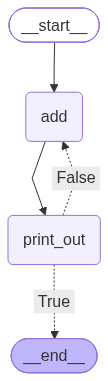

In [192]:
from IPython.display import Image, display
display(Image(count_app.get_graph().draw_mermaid_png()))

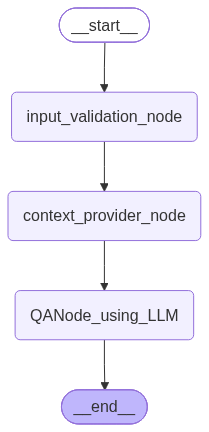

In [193]:
from IPython.display import Image, display
display(Image(Q_A_App.get_graph().draw_mermaid_png()))

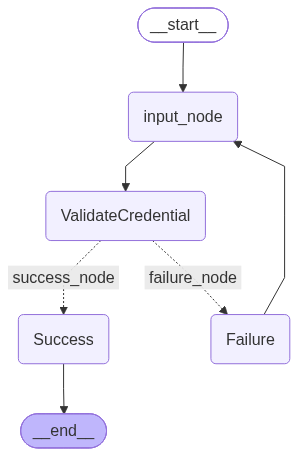

In [194]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))